In [5]:
import pandas as pd
import numpy as np
df_cardiac = pd.read_csv("cleaned/cardiac_cleaned.csv")
df_demography = pd.read_csv("cleaned/demography_cleaned.csv")
df_hospitalization = pd.read_csv("cleaned/hospitalization_discharge_cleaned.csv")
df_labs = pd.read_csv("cleaned/labs_cleaned.csv")
df_patienthistory = pd.read_csv("cleaned/patienthistory_cleaned.csv")
df_prescriptions = pd.read_csv("cleaned/precriptions_cleaned.csv")
df_responsiveness = pd.read_csv("cleaned/responsivenes_cleaned.csv")


In [6]:
df_cardiac.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   patient_id                   2008 non-null   int64  
 1   heart_failure_severity       2008 non-null   int64  
 2   heart_damage_level           2008 non-null   int64  
 3   heart_attack_history         2008 non-null   int64  
 4   congestive_heart_failure     2008 non-null   int64  
 5   peripheral_vascular_disease  2008 non-null   int64  
 6   heart_failure_type           2008 non-null   str    
 7   heart_pumping_efficiency     635 non-null    float64
 8   left_ventricle_size          1311 non-null   float64
 9   mitral_valve_ems             969 non-null    float64
 10  mitral_valve_ams             543 non-null    float64
 11  ea_ratio                     393 non-null    float64
 12  pulmonary_velocity           790 non-null    float64
 13  pulmonary_pressure           

In [8]:
history = pd.read_csv("cleaned/patienthistory_cleaned.csv")

print(history.columns.tolist())

['patient_id', 'cerebrovascular_disease', 'dementia', 'chronic_obstructive_pulmonary_disease', 'connective_tissue_disease', 'peptic_ulcer_disease', 'diabetes', 'moderate_to_severe_chronic_kidney_disease', 'hemiplegia', 'leukemia', 'malignant_lymphoma', 'solid_tumor', 'liver_disease', 'aids', 'cci_score', 'type2_respiratory_failure', 'acute_renal_failure']


In [13]:
master_df = (
    df_demography
    .merge(df_cardiac, on='patient_id', how='left')
    .merge(df_hospitalization, on='patient_id', how='left')
    .merge(df_patienthistory, on='patient_id', how='left')
    .merge(df_labs, on='patient_id', how='left')
    .merge(df_prescriptions, on='patient_id', how='left')
    .merge(df_responsiveness, on='patient_id', how='left')
)

print(master_df.shape)
master_df.head()

(15363, 168)


,patient_id,gender,weight,height,bmi,occupation,age_category,heart_failure_severity,heart_damage_level,heart_attack_history,...,O2Hb,anion_gap,free_calcium,total_hemoglobin,drug_name,eye_opening,verbal_response,movement,consciousness,gcs
0,827040,Female,50.0,1.45,23.781213,Unknown,69-79,3,2,0,...,NaN,NaN,NaN,NaN,Meglumine Adenosine Cyclophosphate For Injection,4,5,6,Clear,15
1,827040,Female,50.0,1.45,23.781213,Unknown,69-79,3,2,0,...,NaN,NaN,NaN,NaN,Valsartan Dispersible Tablet,4,5,6,Clear,15
2,827040,Female,50.0,1.45,23.781213,Unknown,69-79,3,2,0,...,NaN,NaN,NaN,NaN,Furosemide Tablet,4,5,6,Clear,15
3,857781,Male,50.0,1.64,18.590125,Urbanresident,69-79,3,3,0,...,95.9,17.8,1.14,125.0,Sulfotanshinone Sodium Injection,4,5,6,Clear,15
4,857781,Male,50.0,1.64,18.590125,Urbanresident,69-79,3,3,0,...,95.9,17.8,1.14,125.0,Furosemide Tablet,4,5,6,Clear,15


In [15]:
master_df = master_df.copy()

In [16]:
comorbidity_cols = [
    'cerebrovascular_disease',
    'dementia',
    'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'hemiplegia',
    'leukemia',
    'malignant_lymphoma',
    'solid_tumor',
    'liver_disease',
    'aids',
    'type2_respiratory_failure',
    'acute_renal_failure'
]

In [17]:
master_df['comorbidity_count'] = (
    master_df[comorbidity_cols]
    .sum(axis=1)
)

In [18]:
master_df = (
    df_demography
    .merge(df_cardiac, on='patient_id', how='left')
    .merge(df_hospitalization, on='patient_id', how='left')
    .merge(df_patienthistory, on='patient_id', how='left')
    .merge(df_labs, on='patient_id', how='left')
    .merge(df_prescriptions, on='patient_id', how='left')
    .merge(df_responsiveness, on='patient_id', how='left')
)

# Defragment dataframe
master_df = master_df.copy()

In [19]:
master_df['comorbidity_count'] = (
    master_df[comorbidity_cols]
    .sum(axis=1)
)

In [20]:
master_df['comorbidity_count'].value_counts().sort_index()

comorbidity_count
0.0    6143
1.0    5801
2.0    2688
3.0     620
4.0     111
Name: count, dtype: int64

In [21]:
master_df['comorbidity_count'] = (
    master_df[comorbidity_cols]
    .fillna(0)
    .sum(axis=1)
)

In [24]:
master_df = master_df.copy()

master_df['comorbidity_count'] = (
    master_df[comorbidity_cols]
    .fillna(0)
    .astype(int)
    .sum(axis=1)
)

master_df[['patient_id','comorbidity_count']].head()

,patient_id,comorbidity_count
0,827040,0
1,827040,0
2,827040,0
3,857781,2
4,857781,2


In [27]:
# Mortality by comorbidity burden
master_df.groupby('comorbidity_count')['death_6m'].mean()*100


comorbidity_count
0     2.018558
1     2.413377
2     2.492560
3     7.258065
4    18.018018
Name: death_6m, dtype: float64

In [26]:


# Readmission by comorbidity burden
master_df.groupby('comorbidity_count')['readmission_6m'].mean()*100

comorbidity_count
0    35.015465
1    41.785899
2    43.973214
3    47.419355
4    61.261261
Name: readmission_6m, dtype: float64

##  Which medications are most commonly prescribed?

In [28]:
top_drugs = (
    df_prescriptions['drug_name']
    .value_counts()
    .reset_index()
)

top_drugs.columns = [
    'Medication',
    'Prescription_Count'
]

top_drugs.head(20)

,Medication,Prescription_Count
0,Spironolactone Tablet,1833
1,Furosemide Injection,1718
2,Furosemide Tablet,1641
3,Meglumine Adenosine Cyclophosphate For Injection,1114
4,Deslanoside Injection,1015
5,Digoxin Tablet,998
6,Aspirin Enteric-Coated Tablet,958
7,Atorvastatin Calcium Tablet,822
8,Milrinone Injection,707
9,Sulfotanshinone Sodium Injection,570


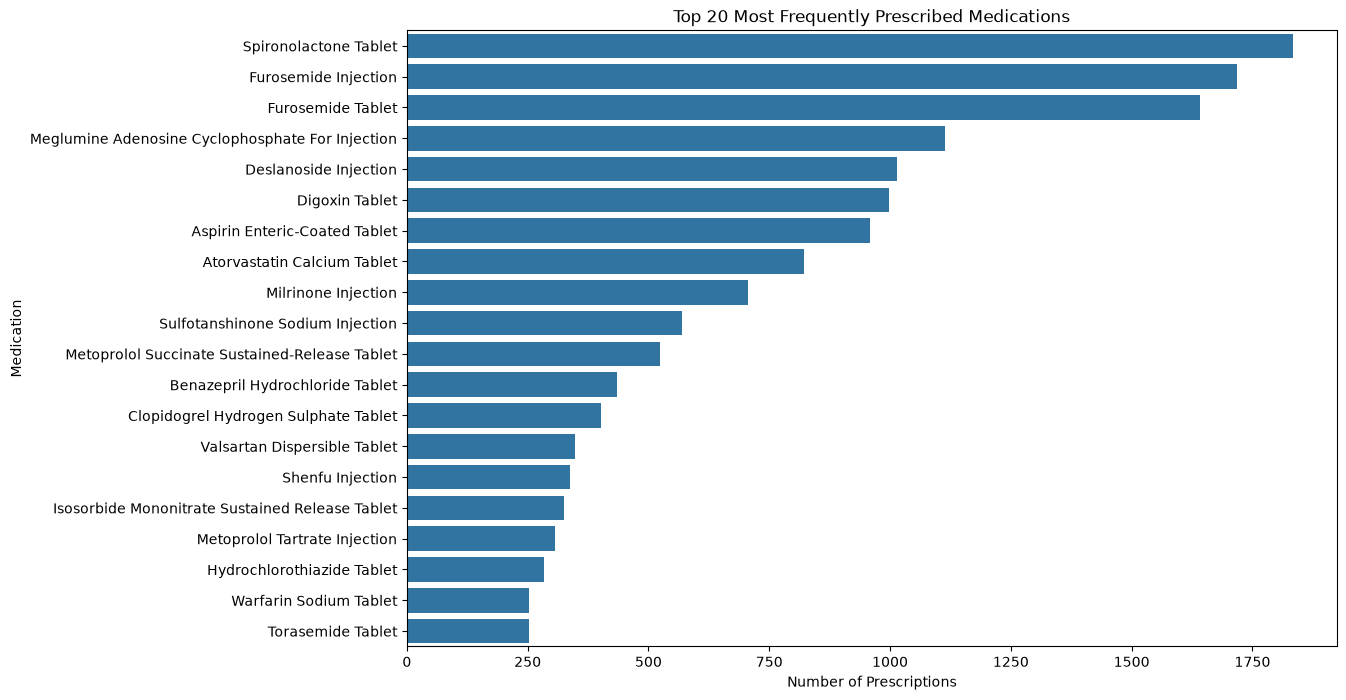

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

top20 = (
    df_prescriptions['drug_name']
    .value_counts()
    .head(20)
    .reset_index()
)

top20.columns = [
    'Medication',
    'Prescription_Count'
]

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x='Prescription_Count',
    y='Medication'
)

plt.title("Top 20 Most Frequently Prescribed Medications")
plt.xlabel("Number of Prescriptions")
plt.ylabel("Medication")

plt.show()

## Which laboratory markers are strongest mortality indicators?

In [30]:
death_6m = 1   # Died within 6 months
death_6m = 0   # Survived

In [31]:
df_labs.columns.tolist()


['patient_id',
 'temp',
 'pulse',
 'resp',
 'sbp',
 'dbp',
 'MAP',
 'FiO2',
 'creatinine',
 'urea',
 'uric_acid',
 'glomerular_filtration_rate',
 'cystatin',
 'WBC',
 'monocyte_ratio',
 'monocyte_count',
 'RBC',
 'coefficient_of_variation_RBC_DistributionWidth',
 'Standard_Deviation_RBC_DistributionWidth',
 'MCV',
 'HCT',
 'lymphocyte_count',
 'MCH',
 'MCHC',
 'MPV',
 'basophil_ratio',
 'basophil_count',
 'eosinophil_ratio',
 'eosinophil_count',
 'hemoglobin',
 'platelet',
 'platelet_distribution_width',
 'platelet_hematocrit',
 'neutrophil_ratio',
 'neutrophil_count',
 'd_dimer',
 'international_normalized_ratio',
 'activated_partial_thromboplastin_time',
 'thrombin_time',
 'prothrombin_activity',
 'prothrombin_time_ratio',
 'fibrinogen',
 'high_sensitivity_troponin',
 'myoglobin',
 'CO2_capacity',
 'calcium',
 'potassium',
 'chloride',
 'sodium',
 'phosphorus',
 'magnesium',
 'creatine_kinase_isoenzyme_to_creatine_kinase',
 'hydroxybutyrate_dehydrogenase_to_lactate_dehydrogenase',
 '

In [33]:
lab_cols = ['patient_id',
 'temp',
 'pulse',
 'resp',
 'sbp',
 'dbp',
 'MAP',
 'FiO2',
 'creatinine',
 'urea',
 'uric_acid',
 'glomerular_filtration_rate',
 'cystatin',
 'WBC',
 'monocyte_ratio',
 'monocyte_count',
 'RBC',
 'coefficient_of_variation_RBC_DistributionWidth',
 'Standard_Deviation_RBC_DistributionWidth',
 'MCV',
 'HCT',
 'lymphocyte_count',
 'MCH',
 'MCHC',
 'MPV',
 'basophil_ratio',
 'basophil_count',
 'eosinophil_ratio',
 'eosinophil_count',
 'hemoglobin',
 'platelet',
 'platelet_distribution_width',
 'platelet_hematocrit',
 'neutrophil_ratio',
 'neutrophil_count',
 'd_dimer',
 'international_normalized_ratio',
 'activated_partial_thromboplastin_time',
 'thrombin_time',
 'prothrombin_activity',
 'prothrombin_time_ratio',
 'fibrinogen',
 'high_sensitivity_troponin',
 'myoglobin',
 'CO2_capacity',
 'calcium',
 'potassium',
 'chloride',
 'sodium',
 'phosphorus',
 'magnesium',
 'creatine_kinase_isoenzyme_to_creatine_kinase',
 'hydroxybutyrate_dehydrogenase_to_lactate_dehydrogenase',
 'hydroxybutyrate_dehydrogenase',
 'glutamic_oxaloacetic_transaminase',
 'creatine_kinase',
 'creatine_kinase_isoenzyme',
 'lactate_dehydrogenase',
 'brain_natriuretic_peptide',
 'high_sensitivity_protein',
 'nucleotidase',
 'fucosidase',
 'albumin',
 'white_globulin_ratio',
 'glutamyltranspeptidase',
 'glutamic_pyruvic_transaminase',
 'glutamic_oxaliplatin',
 'indirect_bilirubin',
 'ALP',
 'globulin',
 'direct_bilirubin',
 'total_bilirubin',
 'total_bile_acid',
 'total_protein',
 'erythrocyte_sedimentation_rate',
 'cholesterol',
 'LDL_C',
 'triglyceride',
 'HDL_C',
 'homocysteine',
 'apolipoprotein_a',
 'apolipoprotein_b',
 'lipoprotein',
 'pH',
 'standard_residual_base',
 'standard_bicarbonate',
 'pCO2',
 'tCO2',
 'methemoglobin',
 'HCT_BG',
 'HHb',
 'K_ion',
 'Cl_ion',
 'Na_ion',
 'glucose_blood_gas',
 'lactate',
 'measured_residual_base',
 'HCO3_act',
 'CO_Hb',
 'temp_BG',
 'sO2',
 'pO2',
 'O2Hb',
 'anion_gap',
 'free_calcium',
 'total_hemoglobin']

mortality_lab = []

for col in lab_cols:

    survived = master_df.loc[
        master_df['death_6m'] == 0,
        col
    ].mean()

    died = master_df.loc[
        master_df['death_6m'] == 1,
        col
    ].mean()

    difference = abs(died - survived)

    mortality_lab.append([
        col,
        survived,
        died,
        difference
    ])

mortality_lab = pd.DataFrame(
    mortality_lab,
    columns=[
        'Lab_Marker',
        'Survived_Mean',
        'Died_Mean',
        'Difference'
    ]
)

mortality_lab.sort_values(
    'Difference',
    ascending=False
)


,Lab_Marker,Survived_Mean,Died_Mean,Difference
0,patient_id,798981.269326,795510.709596,3470.559730
57,lactate_dehydrogenase,268.600805,400.165680,131.564876
53,hydroxybutyrate_dehydrogenase,212.246677,289.994135,77.747458
10,uric_acid,487.917413,565.553299,77.635886
43,myoglobin,112.929562,179.405875,66.476313
...,...,...,...,...
88,methemoglobin,0.242410,0.260784,0.018375
32,platelet_hematocrit,0.173605,0.186447,0.012842
1,temp,36.406107,36.401263,0.004844
26,basophil_count,0.031649,0.026954,0.004695


In [34]:
from scipy.stats import ttest_ind

results = []

for col in lab_cols:

    dead = master_df.loc[
        master_df['death_6m']==1,
        col
    ].dropna()

    alive = master_df.loc[
        master_df['death_6m']==0,
        col
    ].dropna()

    stat, p = ttest_ind(
        dead,
        alive,
        equal_var=False
    )

    results.append([
        col,
        p
    ])

lab_significance = pd.DataFrame(
    results,
    columns=['Marker','P_Value']
)

lab_significance.sort_values(
    'P_Value'
)

C:\Users\singh\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Marker,P_Value
33,neutrophil_ratio,4.074276e-27
25,basophil_ratio,1.171855e-26
11,glomerular_filtration_rate,5.526408e-23
9,urea,9.791492e-22
12,cystatin,5.817851e-20
...,...,...
72,total_bile_acid,7.354703e-01
74,erythrocyte_sedimentation_rate,7.860124e-01
1,temp,8.408084e-01
2,pulse,9.226644e-01


In [35]:
from sklearn.ensemble import RandomForestClassifier

X = master_df[lab_cols].fillna(
    master_df[lab_cols].median()
)

y = master_df['death_6m']

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X,y)

importance_df = pd.DataFrame({
    'Marker': lab_cols,
    'Importance': rf.feature_importances_
})

importance_df.sort_values(
    'Importance',
    ascending=False
)

,Marker,Importance
7,FiO2,0.029626
104,free_calcium,0.027450
12,cystatin,0.024255
9,urea,0.022827
56,creatine_kinase_isoenzyme,0.019791
...,...,...
74,erythrocyte_sedimentation_rate,0.001744
80,apolipoprotein_a,0.000897
81,apolipoprotein_b,0.000655
82,lipoprotein,0.000494


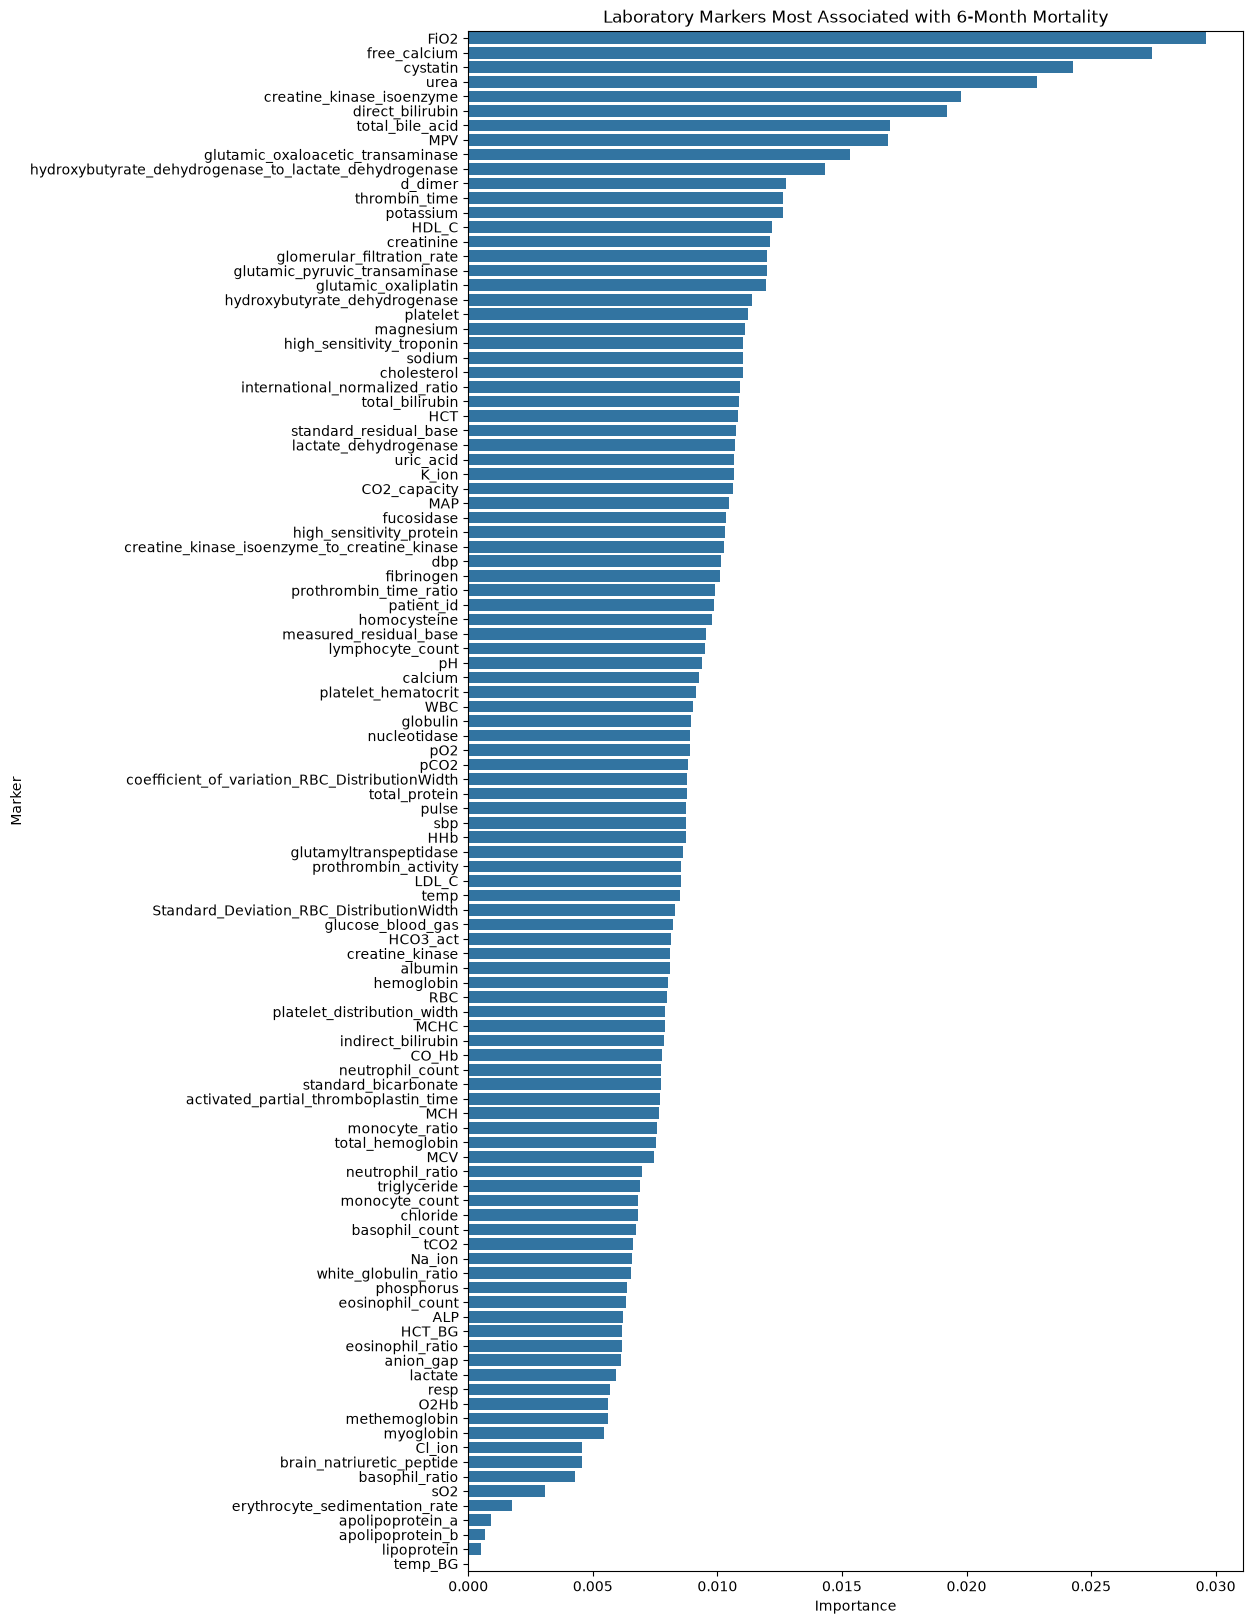

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

top_markers = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

plt.figure(figsize=(10,20))

sns.barplot(
    data=top_markers,
    x='Importance',
    y='Marker'
)

plt.title(
    'Laboratory Markers Most Associated with 6-Month Mortality'
)

plt.show()

## What proportion of patients have each comorbidity (diabetes, CKD, COPD, etc.), and what is the average cci_score by age category? (patienthistory + demography)

## 1 - What proportion of patients have each comorbidity?

In [39]:
comorbidity_cols = [
    'cerebrovascular_disease',
    'dementia',
    'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'hemiplegia',
    'leukemia',
    'malignant_lymphoma',
    'solid_tumor',
    'liver_disease',
    'aids',
    'type2_respiratory_failure',
    'acute_renal_failure'
]

comorbidity_percent = (
    master_df[comorbidity_cols]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

comorbidity_percent.columns = [
    'Comorbidity',
    'Patient_Percentage'
]

print(comorbidity_percent)

                                  Comorbidity  Patient_Percentage
0   moderate_to_severe_chronic_kidney_disease           24.052117
1                                    diabetes           23.829981
2       chronic_obstructive_pulmonary_disease           11.872681
3                     cerebrovascular_disease            7.283734
4                   type2_respiratory_failure            5.728048
5                                    dementia            5.597865
6                               liver_disease            4.267101
7                        peptic_ulcer_disease            2.000261
8                                 solid_tumor            1.763978
9                                  hemiplegia            0.657424
10                        acute_renal_failure            0.325457
11                                       aids            0.208293
12                  connective_tissue_disease            0.117165
13                         malignant_lymphoma            0.071601
14        

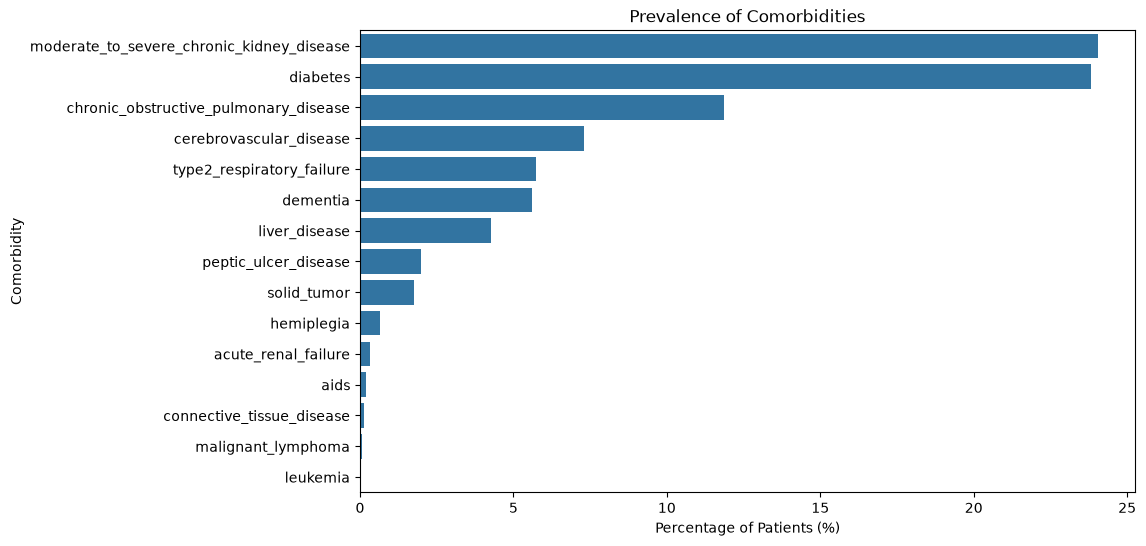

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=comorbidity_percent,
    x='Patient_Percentage',
    y='Comorbidity'
)

plt.xlabel('Percentage of Patients (%)')
plt.ylabel('Comorbidity')
plt.title('Prevalence of Comorbidities')

plt.show()

## 2. Average CGI score by age category

In [41]:
cci_age = (
    master_df.groupby('age_category')['cci_score']
    .mean()
    .reset_index()
    .sort_values('age_category')
)

print(cci_age)

  age_category  cci_score
0        21-29   1.000000
1        29-39   1.370370
2        39-49   1.673333
3        49-59   1.636129
4        59-69   1.764929
5        69-79   1.912898
6        79-89   1.949220
7       89-110   2.007353


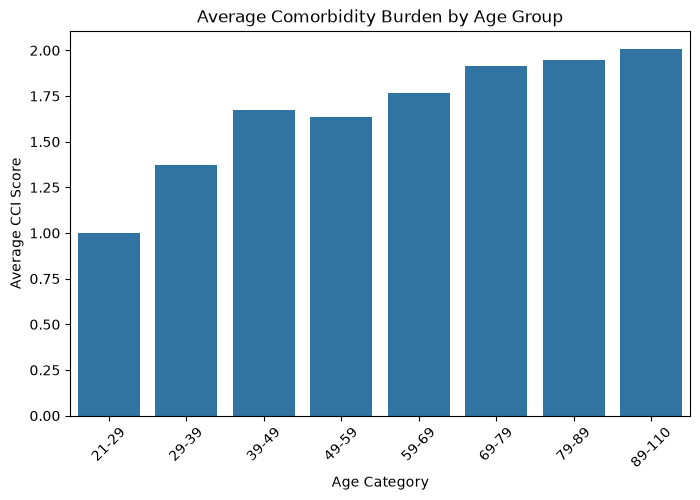

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cci_age,
    x='age_category',
    y='cci_score'
)

plt.xlabel('Age Category')
plt.ylabel('Average CCI Score')
plt.title('Average Comorbidity Burden by Age Group')

plt.xticks(rotation=45)

plt.show()

## 3-Comorbidity Burden Distribution by Age Group

In [43]:
master_df['comorbidity_count'] = (
    master_df[comorbidity_cols]
    .fillna(0)
    .sum(axis=1)
)

burden_age = (
    master_df.groupby('age_category')['comorbidity_count']
    .mean()
    .reset_index()
)

print(burden_age)

  age_category  comorbidity_count
0        21-29           0.000000
1        29-39           0.518519
2        39-49           0.744444
3        49-59           0.713198
4        59-69           0.815835
5        69-79           0.884222
6        79-89           0.947269
7       89-110           0.960294
